In [2]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT / "data" / "raw"
SEA_ANIMALS = RAW_DATA / "sea-animals"
PLASTIC = RAW_DATA / "marine-plastic" / "SOUVIK"


In [3]:
#just making sure paths actually exist
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data: {RAW_DATA}")
print(f"Sea animals: {SEA_ANIMALS}")
print(f"Plastic: {PLASTIC}")

print(f"Plastic exists: {PLASTIC.exists()}")
print(f"Marine animals exist: {SEA_ANIMALS.exists()}")




print("Sea Animal Categories:\n")

for folder in SEA_ANIMALS.iterdir():
    if folder.is_dir():
        print(folder.name)

Project root: d:\Code\Internship_code\marine-debris-classifier
Raw data: d:\Code\Internship_code\marine-debris-classifier\data\raw
Sea animals: d:\Code\Internship_code\marine-debris-classifier\data\raw\sea-animals
Plastic: d:\Code\Internship_code\marine-debris-classifier\data\raw\marine-plastic\SOUVIK
Plastic exists: True
Marine animals exist: True
Sea Animal Categories:

Dolphin
Seal
Sharks
Whale


In [4]:
image_count = 0
for folder in SEA_ANIMALS.iterdir():
    if folder.is_dir():
        images = list(folder.glob("*"))
        print(f"{folder.name}:{len(images)} images")
        image_count += len(images)
print(f"\nTotal Marine Life images: {image_count}")

Dolphin:782 images
Seal:414 images
Sharks:590 images
Whale:572 images

Total Marine Life images: 2358


In [5]:
for split in PLASTIC.iterdir():

    print(split.name)

    if split.is_dir():

        for folder in split.iterdir():

            print(" ", folder.name)


test
  no-plastic
  plastic
train
  no-plastic
  plastic


In [6]:
PROCESSED = PROJECT_ROOT / "data" / "processed"
MARINE_OUT = PROCESSED / "Marine_Life"
PLASTIC_OUT = PROCESSED / "Plastic"

MARINE_OUT.mkdir(parents=True,exist_ok=True)
PLASTIC_OUT.mkdir(parents=True,exist_ok=True)

print("Processed fodlers created")

Processed fodlers created


In [7]:
import random

marine_images = []

species_limits = {
    "Dolphin": 262,
    "Seal": 262,
    "Sharks": 263,
    "Whale": 263,
}

for category in SEA_ANIMALS.iterdir():
    if category.is_dir():

        images = []
        images.extend(category.glob("*.jpg"))
        images.extend(category.glob("*.jpeg"))
        images.extend(category.glob("*.png"))

        images = list(images)
        random.shuffle(images)

        marine_images.extend(images[:species_limits[category.name]])

plastic_images = []

for split in ["train", "test"]:
    plastic_folder = PLASTIC / split / "plastic"
    plastic_images.extend(plastic_folder.glob("*.jpg"))
    plastic_images.extend(plastic_folder.glob("*.jpeg"))
    plastic_images.extend(plastic_folder.glob("*.png"))

print(f"Marine Images: {len(marine_images)}")
print(f"Plastic Images: {len(plastic_images)}")

limit = min(len(marine_images), len(plastic_images))

print(f"Will be using {limit} images from each")

Marine Images: 1050
Plastic Images: 1050
Will be using 1050 images from each


In [8]:
TARGET_SIZE = (224,224)

print("processing images")

for i, image_path in enumerate(marine_images[:limit]):

    img = Image.open(image_path)

    img = img.convert("RGB")

    img = img.resize(TARGET_SIZE)

    img.save(MARINE_OUT / f"marine_{i:04}.jpg")

print("processing images")

for i, image_path in enumerate(plastic_images[:limit]):

    img = Image.open(image_path)

    img = img.convert("RGB")

    img = img.resize(TARGET_SIZE)

    img.save(PLASTIC_OUT / f"plastic_{i:04}.jpg")


print("Dataset preprocessing complete!")
print(f"Marine Life images saved: {limit}")
print(f"Plastic images saved: {limit}")

processing images
processing images
Dataset preprocessing complete!
Marine Life images saved: 1050
Plastic images saved: 1050


In [9]:
TESTING = PROJECT_ROOT / "data" / "testing"
TEST_MARINE = TESTING / "Marine_Life"
TEST_PLASTIC = TESTING / "Plastic"

TEST_MARINE.mkdir(parents=True, exist_ok=True)
TEST_PLASTIC.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = (224, 224)

# Save remaining marine images
marine_test_images = []

for category in SEA_ANIMALS.iterdir():
    if category.is_dir():

        images = []
        images.extend(category.glob("*.jpg"))
        images.extend(category.glob("*.jpeg"))
        images.extend(category.glob("*.png"))

        images = list(images)

        marine_test_images.extend(images[species_limits[category.name]:])

for i, image_path in enumerate(marine_test_images):

    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img = img.resize(TARGET_SIZE)
        img.save(TEST_MARINE / f"marine_test_{i:04}.jpg")


# Save remaining plastic images
plastic_test_images = plastic_images[limit:]

for i, image_path in enumerate(plastic_test_images):

    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img = img.resize(TARGET_SIZE)
        img.save(TEST_PLASTIC / f"plastic_test_{i:04}.jpg")

print("Testing dataset created!")
print(f"Marine test images: {len(marine_test_images)}")
print(f"Plastic test images: {len(plastic_test_images)}")

Testing dataset created!
Marine test images: 1308
Plastic test images: 0


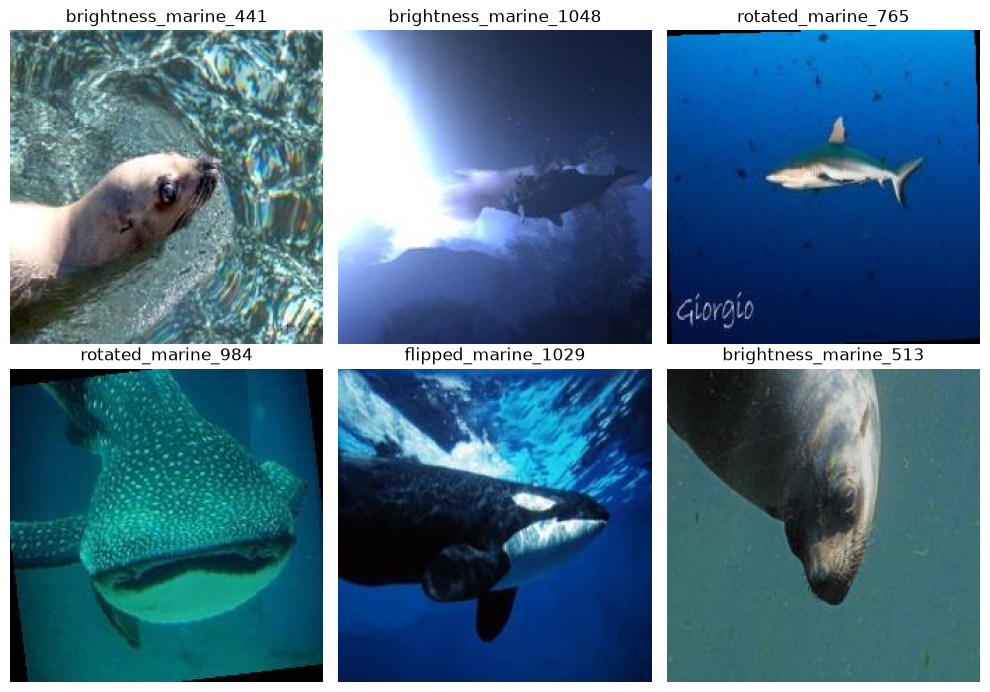

In [10]:
import random

sample_images = random.sample(
    list(MARINE_OUT.glob("*.jpg")),
    6
)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax, image_path in zip(axes.flatten(), sample_images):

    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(image_path.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()


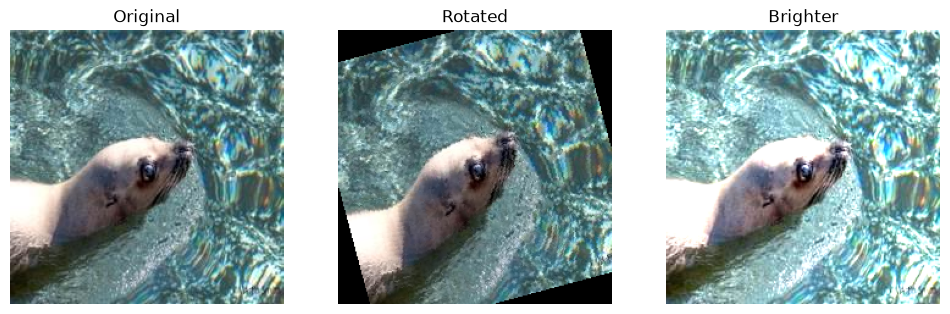

In [11]:
from PIL import Image, ImageEnhance

sample = Image.open(sample_images[0])

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample)
plt.title("Original")
plt.axis("off")

rotated = sample.rotate(
    angle=15,
    expand=False,
    fillcolor=(0, 0, 0)
)

plt.subplot(1, 3, 2)
plt.imshow(rotated)
plt.title("Rotated")
plt.axis("off")

enhancer = ImageEnhance.Brightness(sample)
bright = enhancer.enhance(1.5)

plt.subplot(1, 3, 3)
plt.imshow(bright)
plt.title("Brighter")
plt.axis("off")

plt.show()

In [12]:
import random
def augment_images(folder_name,label):

    """Generate rotated, flipped, and brightness-adjusted copies of every image."""
    
    i = 0
    FILE_PATH = PROJECT_ROOT / "data" / "processed" / f"{folder_name}"
    original_images = list(FILE_PATH.iterdir())

    for picture in original_images:
        i += 1
        brightness_factor = random.uniform(0.8, 1.2)
        rotate_factor = random.randint(-15, 15)


        with Image.open(picture) as img:
            rotated_img = img.rotate(rotate_factor)
            rotated_img.save(FILE_PATH / f"rotated_{label}_{i}.jpg")

            flipped_img = img.transpose(Image.FLIP_LEFT_RIGHT)
            flipped_img.save(FILE_PATH / f"flipped_{label}_{i}.jpg")

            enhancer = ImageEnhance.Brightness(img)
            brightness_img = enhancer.enhance(brightness_factor)
            brightness_img.save(FILE_PATH / f"brightness_{label}_{i}.jpg")


# WARNING: Creates 3 augmented images for every original image (dataset becomes 4x larger).
run_augmentation = False
# EACHTIME

if run_augmentation:
    augment_images("Marine_Life","marine")
    augment_images("Plastic","plastic")


In [13]:
def train_model(): 
    import tensorflow as tf
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    print(f"TensorFlow Version: {tf.__version__}")

    #PROJECT_ROOT = Path.cwd().parent

    IMAGE_SIZE = (224,224)
    BATCH_SIZE = 32

    # creatig object
    train_datagen = ImageDataGenerator(
        rescale=1.0/255,
        validation_split = 0.3
    )

    DATASET_DIR = PROJECT_ROOT / "data" / "processed"

    print(DATASET_DIR)


    train_generator = train_datagen.flow_from_directory(
        
        DATASET_DIR,
        target_size = IMAGE_SIZE,
        batch_size = BATCH_SIZE,
        class_mode =  "binary",
        subset = "training",
        shuffle = True
    )

    validation_generator = train_datagen.flow_from_directory(
        
        DATASET_DIR,
        target_size = IMAGE_SIZE,
        batch_size = BATCH_SIZE,
        class_mode =  "binary",
        subset = "validation",
        shuffle = False
    )

    print(train_generator.class_indices)


    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224,224,3),
        include_top=False,
        weights= "imagenet"
    )

    base_model.trainable = False

    print("Loaded Base Model") 


    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    print("Classification head added")



    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    print("Model compiled\n\n\n\n")


    model.summary()




    history = model.fit(
        train_generator,
        validation_data = validation_generator,
        epochs = 10
    )

In [14]:
model.save("marine_classifier.h5")

print("Model saved successfully!")

NameError: name 'model' is not defined

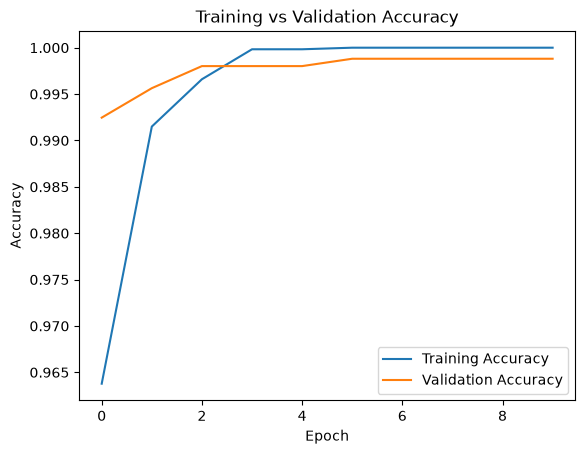

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

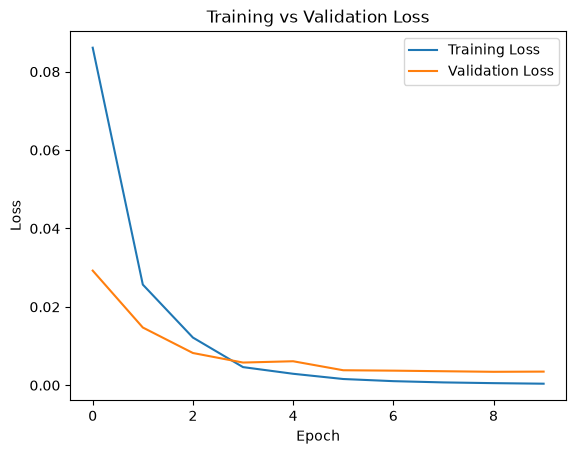

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
def testing_on_unseen_data():
    test_datagen = ImageDataGenerator(rescale = 1.0/255)

    #TESTING = PROJECT_ROOT / "data" / "testing"

    test_dataset = test_datagen.flow_from_directory(
        "data/testing",
        targe_size = (24,224),
        batch_size = 32,
        class_mode = "binary",
        shuffle = False
    )

    test_loss, test_accuracy = model.evaluate(test_dataset)

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Acuraacy: {test_accuracy:.4f}")

    print(test_dataset.class_indices)



testing_on_unseen_data()

NameError: name 'ImageDataGenerator' is not defined